*Put your input image files in `data/input`.*

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_log, blob_dog, blob_doh, corner_harris, corner_peaks
np.random.seed(42)
H, W = 256, 256 # Image dimensions

## Helper Functions

In [2]:
def read_image(filename, format='gray'):
    """
    Read image from file and convert to specified format.
    """
    basepath = os.path.curdir
    img = cv2.imread(os.path.join(basepath, 'data', 'input', filename))
    if format == 'gray':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    elif format == 'rgb':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    return img.astype(np.float64)

In [3]:
def make_blob_image(
    radii: list = [4, 8, 16, 32, 64],
    size: int = 256,
    overlap: float = 0.0,
) -> tuple:
    """
    Synthetic black image with white filled circles of given radii.
    Circles are placed left-to-right with controlled spacing.

    Parameters
    ----------
    radii   : list of int — radii of circles to draw
    size    : int         — image is (size x size)
    overlap : float       — fraction of the smaller circle's radius
                           by which adjacent circles may overlap.
                           0.0  = circles just touch (default, no overlap)
                           0.5  = circles overlap by 50% of the smaller radius
                           -0.5 = extra gap equal to 50% of the smaller radius

    Returns
    -------
    img     : np.ndarray (size, size, uint8)
    centres : list of (cx, cy) tuples
    """
    img = np.zeros((size, size), dtype=np.uint8)
    centres = []
    cy = size // 2

    # Place first circle: its left edge starts at one radius from the border
    cx = radii[0] + 5

    for i, r in enumerate(radii):
        centres.append((cx, cy))
        cv2.circle(img, (cx, cy), r, 255, -1)

        if i < len(radii) - 1:
            r_next = radii[i + 1]
            gap = overlap * min(r, r_next)
            # next centre = current centre + current radius + next radius - gap
            cx = cx + r + r_next - int(gap)

    return img, centres

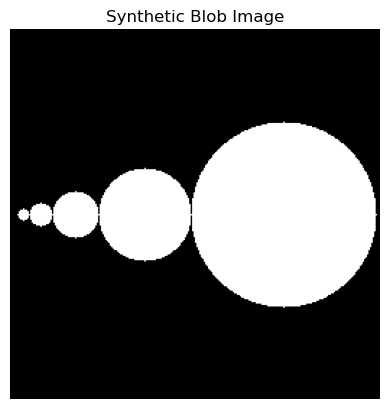

In [4]:
sample_blob_img = make_blob_image(overlap=0.0)
plt.imshow(sample_blob_img[0], cmap='gray'); plt.title('Synthetic Blob Image'); plt.axis('off'); plt.show()

In [5]:
def make_ellipse_image(
    aspect_ratios: list = [2.0, 3.0, 4.0],
    base_radius: int = 40,
    size: int = 256,
    gap_px: int = 5,
    angle: float = 90.0,
) -> tuple:
    """
    Synthetic black image with white filled ellipses of varying aspect ratios.
    Major axis is always base_radius; minor axis = base_radius / aspect_ratio.

    Parameters
    ----------
    aspect_ratios : list of float — major/minor axis ratio.
                    1.0 = circle, 2.0 = twice as wide as tall, etc.
    base_radius   : int   — length of the major axis (semi-axis a) in pixels
    size          : int   — image is (size x size)
    gap_px        : int   — fixed pixel gap between adjacent ellipses
    angle         : float — rotation of all ellipses in degrees (0 = horizontal)

    Returns
    -------
    img     : np.ndarray (size x size, uint8)
    centres : list of (cx, cy) tuples
    axes    : list of (a, b) tuples — (major, minor) semi-axes for each ellipse
    """
    img = np.zeros((size, size), dtype=np.uint8)
    centres = []
    axes_list = []
    cy = size // 2
    cx = base_radius + gap_px   # left margin for first ellipse

    for i, ar in enumerate(aspect_ratios):
        a = base_radius                     # major semi-axis (horizontal)
        b = max(1, int(base_radius / ar))   # minor semi-axis (vertical)

        centres.append((cx, cy))
        axes_list.append((a, b))
        cv2.ellipse(img, (cx, cy), (a, b), angle, 0, 360, 255, -1)

        if i < len(aspect_ratios) - 1:
            # next centre clears current major axis + next major axis + gap
            cx = cx + a + base_radius + gap_px

    return img, centres, axes_list

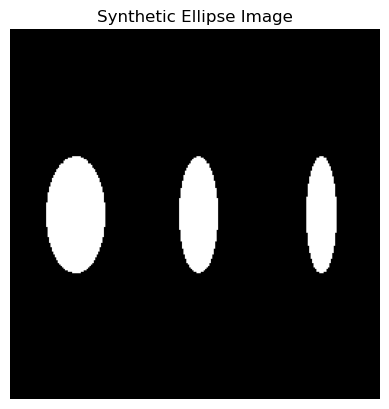

In [65]:
sample_ellipse_img = make_ellipse_image()
plt.imshow(sample_ellipse_img[0], cmap='gray'); plt.title('Synthetic Ellipse Image'); plt.axis('off'); plt.show()

In [7]:
def rotate_image(image: np.ndarray, angle_deg: float) -> np.ndarray:
    """Rotate image about its centre. Empty regions are filled with black."""
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    return cv2.warpAffine(image, M, (w, h))

In [10]:
def plot_1d(signals, labels=None, title=None, xlabel='Pixel', ylabel='Intensity', figsize=(10, 3.5)):
    labels = list(labels or []) + [f"Signal {i+1}" for i in range(len(labels or []), len(signals))]
    fig, ax = plt.subplots(figsize=figsize)
    for signal, label in zip(signals, labels):
        ax.plot(signal, label=label, linewidth=1.5)
    ax.set_title(title or '', fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return fig, ax

## Question 1: Edge Detection

### (1a) Compute and visualise image gradients manually

1. Use `cv2.filter2D()` and the Sobel kernels $S_x \text{ and } S_y$ defined explicitly as NumPy arrays **(do not use `cv2.Sobel()` directly** — define the kernels yourself), and apply both to a greyscale image (any image of your choice).

2. Compute:
* Gradient components $G_x$ and $G_y$ at each pixel
* Gradient magnitude $\mid G \mid$ at each pixel
* Gradient orientation $\theta$ at each pixel

3. Visualise all four outputs. Use cmap='hsv' for the direction map so angular values are visually distinct. 

4. What do you notice about where the magnitude is large vs. where the direction is meaningful?

In [67]:
# Helper functions
def compute_gradient(image):
    Sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    Sy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)
    
    Gx = cv2.filter2D(image, cv2.CV_64F, Sx)
    Gy = cv2.filter2D(image, cv2.CV_64F, Sy)
    return Gx, Gy

def compute_magnitude(image):
    Gx, Gy = compute_gradient(image)
    return np.sqrt(Gx**2 + Gy**2)

def compute_orientation(image):
    Gx, Gy = compute_gradient(image)
    return np.arctan2(Gy, Gx)

def plot_image(image, title):
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def plot_image_gradients(Gx, Gy, magnitude, orientation):
    plt.figure(figsize=(14, 10))

    # Horizontal Gradient
    plt.subplot(2, 2, 1)
    plt.imshow(Gx, cmap='gray')
    plt.title('Gradient Component $G_x$ (Horizontal)')
    plt.colorbar()

    # Vertical Gradient
    plt.subplot(2, 2, 2)
    plt.imshow(Gy, cmap='gray')
    plt.title('Gradient Component $G_y$ (Vertical)')
    plt.colorbar()

    # Gradient Magnitude
    plt.subplot(2, 2, 3)
    plt.imshow(magnitude, cmap='gray')
    plt.title('Gradient Magnitude $|G|$')
    plt.colorbar()

    # Gradient Orientation
    plt.subplot(2, 2, 4)
    plt.imshow(orientation, cmap='hsv') # 'hsv' is cyclic, perfect for angular data
    plt.title('Gradient Orientation $\\theta$')
    plt.colorbar(label='Radians')

    plt.tight_layout()
    plt.show()

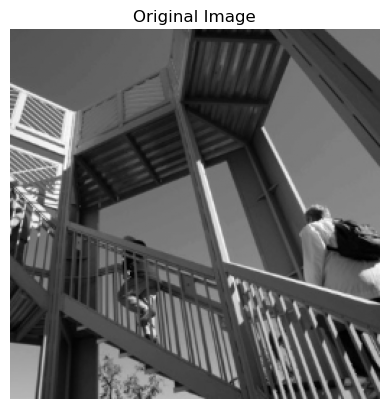

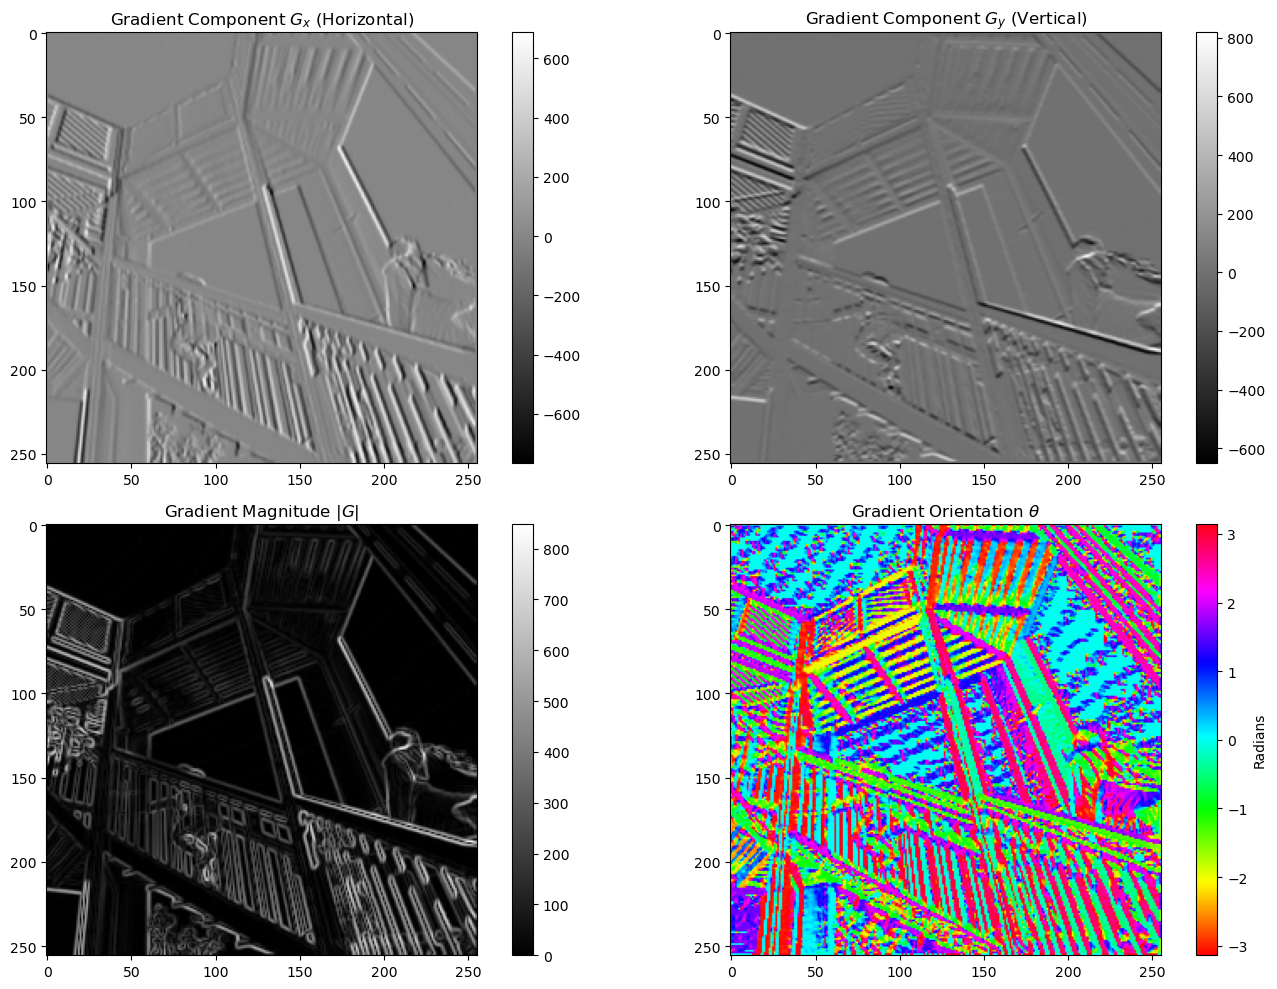

In [68]:
img = read_image('greyscale_image.jpg')

# Calculate magnitude and orientation
Gx, Gy = compute_gradient(img)
magnitude = compute_magnitude(img)
orientation = compute_orientation(img)

# Plot
plot_image(img, 'Original Image')
plot_image_gradients(Gx, Gy, magnitude, orientation)

#### Answer
- Where the magnitude is large: The gradient magnitude $|G|$ is significantly large only at regions of rapid intensity transitions—specifically along edges or object boundaries. In flat regions like backgrounds, the magnitude drops to or near zero.
- Where the direction is meaningful: The calculated direction $\theta$ is only reliable and physically meaningful where the magnitude is large

### (1b) Noise sensitivity of Derivatives

1. Derivatives amplify noise. Verify this by:

* Adding Gaussian noise $(\sigma_{noise}=15)$ to your image
* Computing gradient magnitude on the noisy image without any pre-smoothing
* Computing gradient magnitude *with* Gaussian pre-smoothing at three different scales

2. Plot the gradient magnitude cross-section through a known edge for all four cases using `plot_1d()`. 

3. How does increasing $\sigma$ affect: (a) the noise in the gradient, and (b) the sharpness and position of the edge response? What is the fundamental trade-off being made here?


In [52]:
# Helper functions
def compute_magnitudes_smoothed(noisy_img, sigmas):
    magnitudes_smoothed = []
    for sigma in sigmas:
        smoothed_img = cv2.GaussianBlur(noisy_img, (0, 0), sigmaX=sigma, sigmaY=sigma)
        magnitude = compute_magnitude(smoothed_img)
        magnitudes_smoothed.append(magnitude)
    return magnitudes_smoothed

def plot_grad_mag_cross_section(magnitude_no_smoothing, magnitudes_smoothed):
    row_idx = 128
    x_axis = np.arange(img.shape[1])
    
    plt.figure(figsize=(14, 10))
    plt.plot(x_axis, magnitude_no_smoothing[row_idx, :], label='No Smoothing ($\sigma=0$)', alpha=0.6)
    plt.plot(x_axis, magnitudes_smoothed[0][row_idx, :], label='Smoothed ($\sigma=1$)', linewidth=2)
    plt.plot(x_axis, magnitudes_smoothed[1][row_idx, :], label='Smoothed ($\sigma=3$)', linewidth=2)
    plt.plot(x_axis, magnitudes_smoothed[2][row_idx, :], label='Smoothed ($\sigma=5$)', linewidth=2)
    
    plt.title('1D Cross-Section of Gradient Magnitude Across an Edge')
    plt.xlabel('Pixel X-Coordinate')
    plt.ylabel('Gradient Magnitude')
    plt.legend()
    plt.grid(True)
    plt.show()

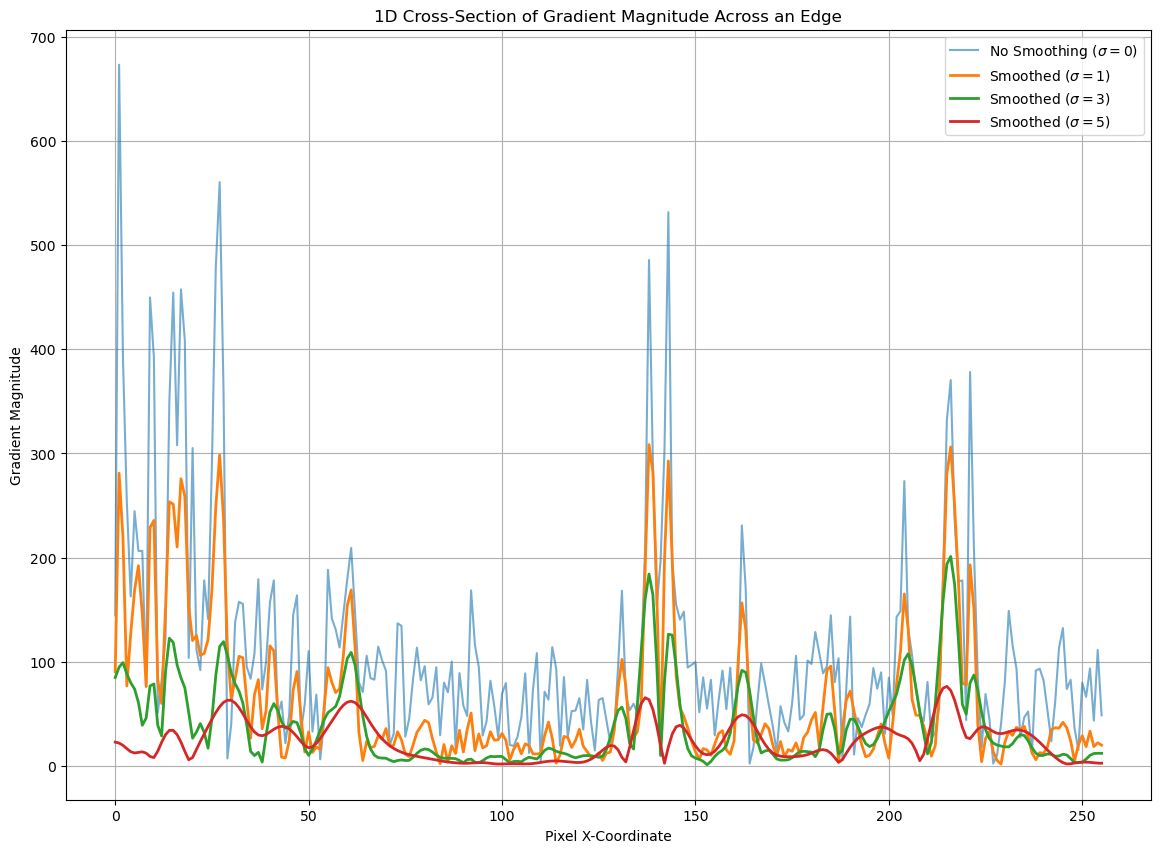

In [69]:
sigma_noise = 15
sigmas = [1, 2, 4]

noise = np.random.normal(0, sigma_noise, img.shape)
noisy_img = img + noise
noisy_img = np.clip(noisy_img, 0, 255)

# Calculate magnitude with and without Gaussian pre-smoothing
magnitude_no_smoothing = compute_magnitude(noisy_img)
magnitudes_smoothed = compute_magnitudes_smoothed(noisy_img, sigmas)

# Plot
plot_grad_mag_cross_section(magnitude_no_smoothing, magnitudes_smoothed)

#### Answer
(a) How increasing $\sigma$ affects noise in the gradient
- Effect: Increasing $\sigma$ drastically reduces noise spikes in the gradient magnitude.
- Reasoning: Taking derivatives operates like a high-pass filter; it calculates differences between neighboring pixels. High-frequency random noise creates large pixel-to-pixel differences, causing massive, erratic spikes in the gradient. A Gaussian filter functions as a low-pass filter. Increasing $\sigma$ averages out these rapid intensity fluctuations over a wider window, attenuating high-frequency noise before the derivative operator can amplify it.

(b) How increasing $\sigma$ affects sharpness and position of the edge response
- Sharpness: Increasing $\sigma$ decreases the sharpness of the edge response. The peak of the gradient magnitude becomes wider, flatter, and more smeared across neighboring pixels instead of being a sharp localized spike.
- Position: The true spatial position of the peak remains centered at the exact location of the edge (due to the symmetric properties of the Gaussian kernel), but identifying the precise center point becomes harder because the peak is structurally blunted.

(c) The fundamental trade-off
- Low Smoothing (Small $\sigma$):
  - Bad noise reduction: Gradients are corrupted by random noise
  - High edge localization: Precise spatial pinpointing of boundaries
- High Smoothing (Large $\sigma$)
  - Good noise reduction: Smooth, clean gradient signals
  - Poor edge localization: Blurred, smeared, and poorly resolved boundaries

### (1c) Comparing Sobel, LoG, and Canny on noisy images

1. On the previously corrupted image apply three edge detectors:

* Sobel (with Gaussian smoothing)
* Laplacian of Gaussian (LoG)- apply `cv2.Laplacian()` after Gaussian smoothing, then threshold zero-crossings
* Canny (experiment with the sigmas and thresholds to get the best results on your image)

2. Visualise the results. Which produces the cleanest, thinnest edges? Which is most sensitive to noise? Discuss why LoG produces double edges at boundaries while Canny does not.

In [57]:
# Helper functions
def get_sobel_edges(image, threshold_val = 50):
    Gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize = 3)
    Gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize = 3)
    magnitude = np.sqrt(Gx**2 + Gy**2)
    _, edge_mask = cv2.threshold(magnitude, threshold_val, 255, cv2.THRESH_BINARY)
    return edge_mask, magnitude

def get_log_edges(image, magnitude_mask=None):    
    laplacian = cv2.Laplacian(image, cv2.CV_64F, ksize=3)
    
    # Locate zero crossings via morphological dilation and erosion
    min_lap = cv2.erode(laplacian, np.ones((3, 3)))
    max_lap = cv2.dilate(laplacian, np.ones((3, 3)))
    
    zero_crossings = np.zeros_like(laplacian, dtype=np.uint8)
    zero_crossings[(min_lap < 0) & (max_lap > 0)] = 255
    
    # Enforce noise mitigation constraint if a mask is passed
    if magnitude_mask is not None:
        _, validation_mask = cv2.threshold(magnitude_mask, 20, 255, cv2.THRESH_BINARY)
        zero_crossings = cv2.bitwise_and(zero_crossings, validation_mask.astype(np.uint8))

    return zero_crossings

def get_canny_edges(image, low_threshold=50, high_threshold=150):
    img_8u = np.clip(image, 0, 255).astype(np.uint8)
    return cv2.Canny(img_8u, low_threshold, high_threshold)

def plot_edge_comparison(original, sobel, log, canny):
    titles = ['Original Noisy', 'Sobel (Thresholded)', 'LoG Zero-Crossings', 'Canny']
    images = [original, sobel, log, canny]
    
    plt.figure(figsize=(14, 10))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

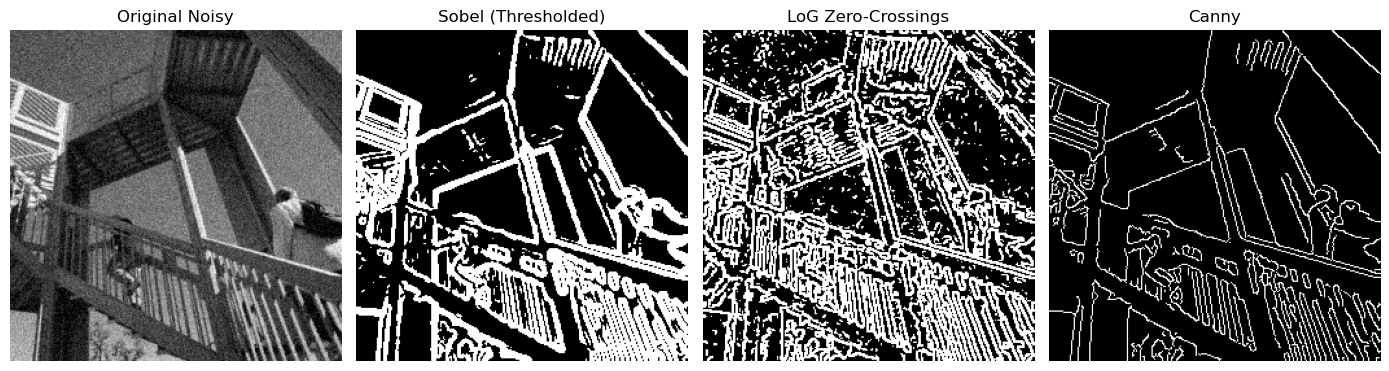

In [64]:
sigma = 1.5
smoothed_img = cv2.GaussianBlur(noisy_img, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Run Edge Detection Functions
sobel_edges, sobel_mag = get_sobel_edges(smoothed_img, 50)
log_edges = get_log_edges(smoothed_img, sobel_mag)
canny_edges = get_canny_edges(smoothed_img, 50, 100)

# Run Final Layout
plot_edge_comparison(noisy_img, sobel_edges, log_edges, canny_edges)

#### Answer
(a) Which produces the cleanest, thinnest edges?
- Canny produces the cleanest and thinnest edges.
- Reason: Canny features an explicit architectural step called Non-Maximum Suppression (NMS). After computing gradient magnitudes, NMS thins down thick edge bands by scanning along the direction of the gradient and preserving only local peak pixels while setting all neighboring non-maximum values to zero. Furthermore, its hysteresis thresholding links broken edge segments together cleanly while throwing out isolated noise spikes.

(b) Which is most sensitive to noise?
- Laplacian of Gaussian (LoG) is inherently the most sensitive to noise.
- Reason: The Laplacian relies on the second derivative ($\nabla^2 I$). While first derivatives (Sobel) amplify noise linearly, second derivatives amplify high-frequency noise quadratically. Even with Gaussian pre-smoothing, tiny remaining noise ripples will cause rapid sign alterations, creating a large number of false-positive zero-crossing edges

(c) Why does LoG produce double edges at boundaries while Canny does not?
- The reason comes down to the underlying calculus of first versus second derivatives.
  - The shape of the derivatives: The first derivative looks like a single peak centered right at the ramp. The second derivative measures acceleration, as the edge starts to rise, it accelerates upward (positive peak), and as it levels off at the top, it decelerates (negative peak)
  - The mechanism of zero-crossings: The true edge is situated precisely where the Laplacian crosses zero between that positive spike and negative spike. However, if the edge is wide, blurry, or has a distinct step thickness, a zero-crossing detection algorithm can register a boundary on both sides of the transition profile
  - Canny's targeted mitigation: Canny avoids this architectural pitfall by tracking the first-derivative peak via Non-Maximum Suppression, which is mentioned at (a).

## Blob Detection

### (2a) LoG Response

Generate a synthetic image, containing a single row of circle of radius $r \in \{4, 8, 16, 32, 64\}$ on a black background (use the provided method ``make_blob_image()``). 

For each image, compute the LoG response at the circle's centre across $\sigma \in [1, 50]$ sampled at 30 points (use ``blob_log()``) and find the $\sigma$ for each detected blob. Plot the response of the cross-section line along the blob centers for each of the 5 detected scales on the same axes using ``plot_1d()``.

### (2b) Relation between $r$ and $\sigma_{peak}$

Plot $r \text{ vs. } \sigma_{peak}$ and fit a line through the origin. What is the slope? The theory predicts $r = \sqrt{2}\,\sigma_{peak}$.

### (2c) Response to Elliptical Blobs

Now test with non-circular blobs: generate ellipses of varying aspect ratios:  $\{1:1,\ 2:1,\ 3:1\}$ using ``make_ellipse_image()``. What $\sigma$ does ``blob_log()`` report for an ellipse? Using $r = \sqrt{2}\,\sigma_{peak}$ is $r$ closer to its major axis length, minor axis length, or their geometric mean? Run the experiment and compare for the diff aspect ratios.

### (2d) Response to Overlapping Blobs

Run ``blob_log()`` on three blob images with varying overlap (generate with `make_blob_image()`) at two overlap tolerance levels: overlap=0.0 (no overlapping blobs allowed) and overlap=0.8 (blobs may overlap significantly). Visualise both. How many blobs does each setting return? When would you want a high overlap tolerance in practice?

### (2e) LoG vs DoH

The `blob_doh()` detector does not use scale-normalised responses- it uses the determinant of the Hessian matrix directly. This makes it very fast but changes its behaviour. Run `blob_doh()` and `blob_log()` on the same natural image (any image of your choice) and compare: which finds larger blobs more reliably? Which is better for small blobs?

## Corner Detection

### (3a) The Harris response map R

Compute the Harris corner response using `corner_harris()` on a grayscale image (any image of your choice). Visualise the full raw $R$ map. From the lecture, $R$ has three regimes.

Identify one example of each regime in your image. Crop and show those three patches side by side with their mean $R$ values as titles.

### (3b) Extracting corners — threshold and spatial suppression

Use `corner_peaks()` to extract corner coordinates from the Harris $R$ map. Sweep two parameters independently:

* `threshold_rel` $\in \{0.001, 0.01, 0.05, 0.1 \}$ (with fixed min_distance=7)
* `min_distance` $\in \{3, 7, 15, 30 \}$ (with fixed threshold_rel=0.02)

For each sweep, draw detected point on the image and show the results. Plot corner count vs each parameter using `plot_1d()`. What is min_distance doing geometrically?

### (3c) Harris is rotation-invariant

Rotate your image by $\{30°, 60°, 90°\}$ using the provided ``rotate_image()`` helper. Run ``corner_harris()`` + ``corner_peaks()`` (with fixed parameters) on the original and all three rotated versions. Report the corner count for each and visualise detections.

Does the count stay roughly constant across rotations? Explain from the definition $R = \det(H) - k(\text{trace}\,H)^2$ why rotation does not change $R$. 

### (3d) Effect of Scale

Resize your image to scales \{0.5\times, 0.75\times, 1.0\times, 1.5\times\} using ``cv2.resize()``. Run ``corner_harris()`` + ``corner_peaks()`` with the same fixed parameters on each. Report and plot corner counts vs scale. Then on the $0.5\times$ image, double the sigma parameter of corner_harris to compensate- what happens to the count? 

Why does Harris fail under scale change despite being rotation-invariant, and what would be needed to make it truly scale-invariant?

### (3e) Harris vs Shi-Tomasi

Compute both response maps on the same image:

* Harris: ``corner_harris()`` (uses $R = \det(H) - k(\text{trace}\,H)^2$ )
* Shi-Tomasi: ``corner_shi_tomasi()`` (uses $R = \min(\lambda_1, \lambda_2)$)

Visualise both response maps side by side. Extract corners from each with ``corner_peaks()`` using the same ``threshold_rel`` and ``min_distance``, draw them, and report the counts. Do the two methods detect corners at the same locations even though the scores differ?

Is there a scenario where Harris would detect a corner that Shi-Tomasi misses, or vice versa?